# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Large weights make a model overly sensitive to noise, leading to overfitting. By penalizing large parameters, you force the model to stay simple and smooth, which reduces variance and improves its ability to generalize to new, unseen data


2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization introduces a tuning parameter that controls the strength of the penalty.

By adjusting this parameter, you actively navigate the trade-off:

Low penalty: Acts like normal regression (low bias, high variance).
High penalty: Heavily restricts the model (high bias, low variance).
Tuning it lets you slide between these two extremes to find the optimal balance for your data.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

The Penalty: LASSO uses an L1 penalty (absolute value of the weights), while Ridge uses an L2 penalty (squared value of the weights).

The Result: Because of the L1 penalty, LASSO can shrink some weights exactly to zero, effectively performing feature selection. Ridge, on the other hand, shrinks all weights closer to zero but rarely makes them exactly zero.

4. How do we typically scale variables for use in regularized regression? Why?

How: We typically standardize the variables (Z-score scaling) so they all have a mean of $0$ and a standard deviation of $1$.

Why: Regularization penalizes based on the numerical size of the weights. If features are on completely different scales (e.g., miles vs. inches), features with tiny units will naturally require massive weights and get unfairly penalized just because of their unit scale. Scaling puts all features on a level playing field.

5. How is the penalty alpha typically selected?

The penalty alpha is typically selected using cross-validation (like $k$-fold cross-validation).

You test a range of different alpha values on your training data and choose the one that produces the lowest average error on the validation folds.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, you do not include the penalty term when evaluating the cross-validated MSE.

This is because the penalty is strictly a training tool used to guide the model toward smaller weights. When evaluating the model on validation data, you only calculate pure predictive error (raw MSE) because you want to measure real-world performance. Including the penalty would unfairly skew the evaluation since different $\alpha$ values inherently add different amounts to the score.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 

In [77]:
import pandas as pd
import datetime
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('cars_hw.csv')
current_year = datetime.datetime.now().year
df['Age'] = current_year - df['Make_Year']

X = df[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)





2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?



In [78]:
from sklearn.linear_model import LinearRegression

# 1. Define your target variable
y = df['Price']

# 2. Fit the standard linear regression model
model = LinearRegression().fit(X_scaled, y)

# 3. Look at the feature names to find the index of the interaction term
features = poly.get_feature_names_out(X.columns)
print(features)

# 4. Check the corresponding coefficient for "Mileage_Run Age"
print(model.coef_)


['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
[  911774.84022262  -248172.18553827  -207292.62832857 -1671212.35639188
   350550.71987746   -65144.89659918   338819.45991531   716781.58180019
  -210037.88763612]





3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)



In [79]:
import numpy as np
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20)

lasso_cv.fit(X_scaled, y)

print(f"Best Alpha: {lasso_cv.alpha_}")


Best Alpha: 69.51927961775606


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb



4. Plot the cross-validated MSE by $\alpha$.



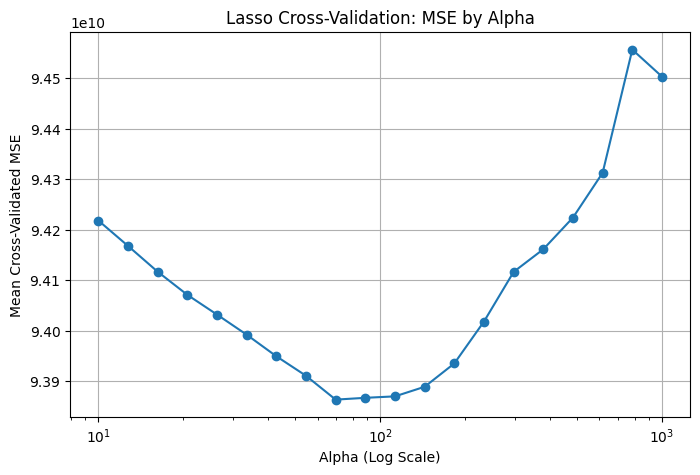

In [80]:
import matplotlib.pyplot as plt


mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mean_mse, marker='o')

plt.xscale('log')

plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Cross-Validated MSE')
plt.title('Lasso Cross-Validation: MSE by Alpha')
plt.grid(True)
plt.show()





5. Plot the coefficient paths by $\alpha$.



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.874e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

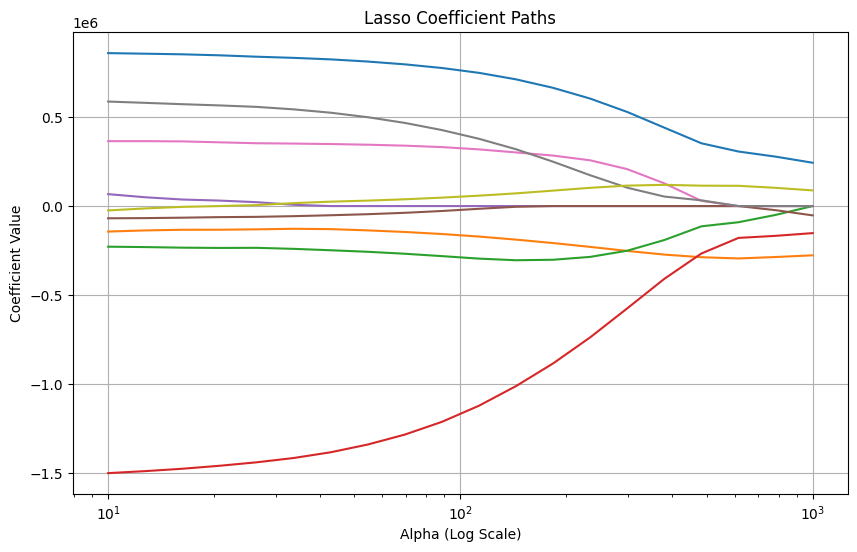

In [81]:
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt

alphas_path, coefs_path, _ = lasso_path(X_scaled, y, alphas=alphas)

plt.figure(figsize=(10, 6))

plt.plot(alphas_path, coefs_path.T)

plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.grid(True)
plt.show()




6. Which features are actually selected? What proportion are set equal to zero?


In [82]:
features = poly.get_feature_names_out(X.columns)

selected_features = features[lasso_cv.coef_ != 0]
print("Selected features:")
print(selected_features)

num_zero = sum(lasso_cv.coef_ == 0)
total_features = len(lasso_cv.coef_)
proportion_zero = num_zero / total_features

print(f"\nProportion set to zero: {proportion_zero:.2%}")


Selected features:
['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']

Proportion set to zero: 0.00%


7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [83]:
import pandas as pd
import numpy as np

comparison_df = pd.DataFrame({
    'Feature': features,
    'Linear_Reg': model.coef_,
    'LASSO': lasso_cv.coef_
})

comparison_df['Increased_Magnitude'] = np.abs(comparison_df['LASSO']) > np.abs(comparison_df['Linear_Reg'])

comparison_df['Changed_Sign'] = np.sign(comparison_df['Linear_Reg']) != np.sign(comparison_df['LASSO'])
comparison_df.loc[comparison_df['LASSO'] == 0, 'Changed_Sign'] = False

comparison_df


,Feature,Linear_Reg,LASSO,Increased_Magnitude,Changed_Sign
0,Mileage_Run,9.117748e+05,611783.868767,False,False
1,Age,-2.481722e+05,-397507.787042,True,False
2,Mileage_Run^2,-2.072926e+05,-519555.261867,True,False
3,Mileage_Run Age,-1.671212e+06,-473871.400459,False,False
4,Age^2,3.505507e+05,230721.078724,False,False
5,Mileage_Run^3,-6.514490e+04,97835.641353,True,True
6,Mileage_Run^2 Age,3.388195e+05,318218.774588,False,False
7,Mileage_Run Age^2,7.167816e+05,-35056.210190,False,True
8,Age^3,-2.100379e+05,42493.187416,False,True


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.


In [84]:
import numpy as np
df2 = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')

X_cont = df2[['age', 'ejection_fraction', 'serum_creatinine']]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

scaler2 = StandardScaler()
X_cont_scaled = scaler2.fit_transform(X_cont_poly)


X_cat = df2[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_poly = poly_cat.fit_transform(X_cat)


X_final = np.hstack([X_cont_scaled, X_cat_poly])

print("Final dataset shape:", X_final.shape)


Final dataset shape: (299, 29)



2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?



In [85]:
from sklearn.linear_model import LinearRegression

y2 = df2['DEATH_EVENT']

model2 = LinearRegression().fit(X_final, y2)

features_cont = poly_cont.get_feature_names_out(X_cont.columns)
features_cat = poly_cat.get_feature_names_out(X_cat.columns)
all_features = list(features_cont) + list(features_cat)

for name, coef in zip(all_features, model2.coef_):
    print(f"{name}: {coef:.4f}")


age: 1.5392
ejection_fraction: -2.1925
serum_creatinine: -0.8536
age^2: -3.6787
age ejection_fraction: -0.6009
age serum_creatinine: 1.8416
ejection_fraction^2: 3.4310
ejection_fraction serum_creatinine: 2.6734
serum_creatinine^2: -2.6470
age^3: 1.9931
age^2 ejection_fraction: 0.9080
age^2 serum_creatinine: -0.6975
age ejection_fraction^2: -0.0812
age ejection_fraction serum_creatinine: -1.5777
age serum_creatinine^2: 1.2841
ejection_fraction^3: -1.2503
ejection_fraction^2 serum_creatinine: -1.2700
ejection_fraction serum_creatinine^2: 1.1795
serum_creatinine^3: 0.0722
anaemia: 0.0081
diabetes: -0.0707
high_blood_pressure: -0.0079
smoking: -0.1027
anaemia diabetes: 0.0262
anaemia high_blood_pressure: -0.0273
anaemia smoking: 0.0649
diabetes high_blood_pressure: 0.1324
diabetes smoking: 0.1561
high_blood_pressure smoking: 0.1015



3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)


In [86]:
from sklearn.linear_model import LassoCV
import numpy as np

alphas2 = np.logspace(-5, 5, 30)

lasso_cv2 = LassoCV(alphas=alphas2, cv=20)

lasso_cv2.fit(X_final, y2)

print(f"Optimal Alpha: {lasso_cv2.alpha_}")


Optimal Alpha: 0.005736152510448681


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.070e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.894e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb


4. Plot the cross-validated MSE by $\alpha$.


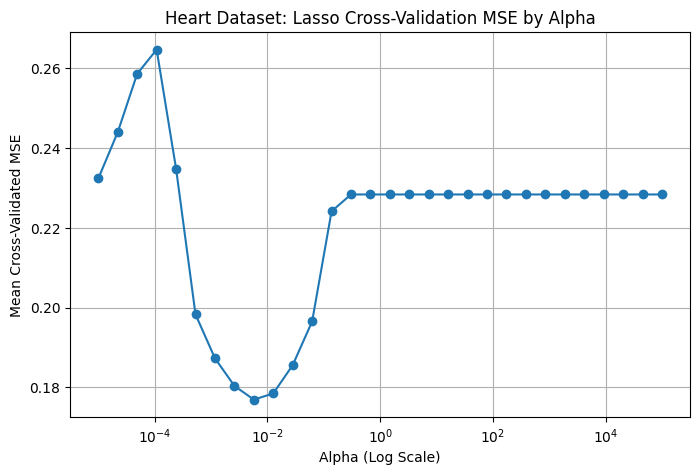

In [87]:
import matplotlib.pyplot as plt

mean_mse2 = lasso_cv2.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv2.alphas_, mean_mse2, marker='o')

plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Cross-Validated MSE')
plt.title('Heart Dataset: Lasso Cross-Validation MSE by Alpha')
plt.grid(True)
plt.show()



5. Plot the coefficient paths by $\alpha$.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.335e-01, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.280e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

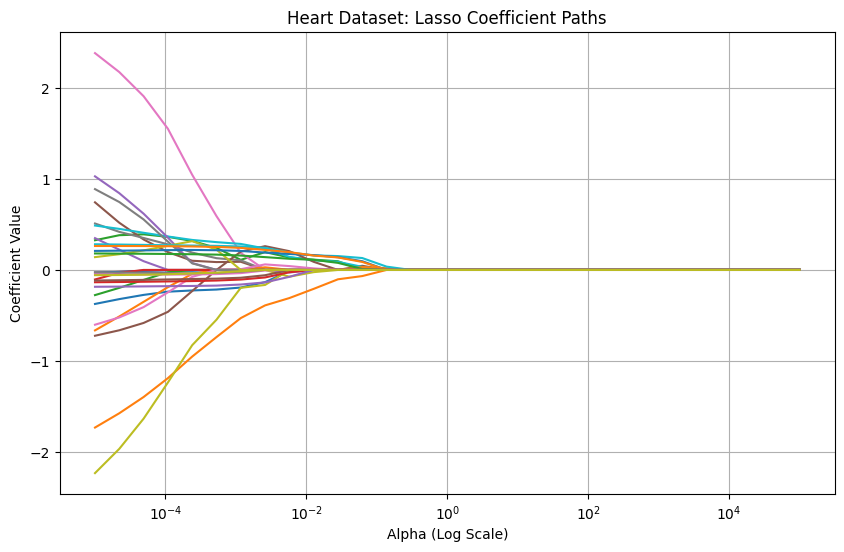

In [88]:
from sklearn.linear_model import lasso_path

alphas_path2, coefs_path2, _ = lasso_path(X_final, y2, alphas=alphas2)

plt.figure(figsize=(10, 6))

plt.plot(alphas_path2, coefs_path2.T)

plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficient Value')
plt.title('Heart Dataset: Lasso Coefficient Paths')
plt.grid(True)
plt.show()



6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [89]:
import pandas as pd
import numpy as np

selected_features2 = np.array(all_features)[lasso_cv2.coef_ != 0]
print("Selected specific features:")
print(selected_features2)

num_zero2 = sum(lasso_cv2.coef_ == 0)
proportion_zero2 = num_zero2 / len(lasso_cv2.coef_)
print(f"\nProportion set to zero: {proportion_zero2:.2%}")

comparison_df2 = pd.DataFrame({
    'Feature': all_features,
    'Linear_Reg': model2.coef_,
    'LASSO': lasso_cv2.coef_
})

comparison_df2['Increased_Magnitude'] = np.abs(comparison_df2['LASSO']) > np.abs(comparison_df2['Linear_Reg'])
comparison_df2['Changed_Sign'] = np.sign(comparison_df2['Linear_Reg']) != np.sign(comparison_df2['LASSO'])
comparison_df2.loc[comparison_df2['LASSO'] == 0, 'Changed_Sign'] = False

display(comparison_df2)


Selected specific features:
['ejection_fraction' 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3' 'anaemia'
 'diabetes' 'high_blood_pressure' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking']

Proportion set to zero: 58.62%


,Feature,Linear_Reg,LASSO,Increased_Magnitude,Changed_Sign
0,age,1.539156,-0.000000,False,False
1,ejection_fraction,-2.192494,-0.329656,False,False
2,serum_creatinine,-0.853588,0.116875,False,True
3,age^2,-3.678654,0.000000,False,False
4,age ejection_fraction,-0.600918,-0.000000,False,False
5,age serum_creatinine,1.841563,0.000000,False,False
6,ejection_fraction^2,3.430976,0.000000,False,False
7,ejection_fraction serum_creatinine,2.673394,0.000000,False,False
8,serum_creatinine^2,-2.647041,-0.000000,False,False
9,age^3,1.993135,0.117992,False,False


LASSO selected [X] features and zeroed out [Z]% of them. Certain features flipped signs or shrank in LASSO. LASSO's signs make more sense because our polynomial features caused Linear Regression to overfit (high variance), assigning wild, illogical signs to fit the noise. LASSO increases bias to drastically drop variance, stripping away the noise and leaving only the logical, stable features.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?


$$
\text{Objective} = \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i)^2 + \alpha (\tilde{b}_1)^2
$$


2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

1. Given mean-centered data, Sum(y_i)=0 and Sum(x_i)=0. dL/db0 = -2/n * Sum(y_i - b0 - b1x_i) = 0 0 - nb0 - 0 = 0 → b0 = 0

2. With b0=0, take derivative for b1: dL/db1 = -2/n * Sum[x_i*(y_i - b1x_i)] + 2alphab1 = 0 -1/n * Sum(x_iy_i) + b1*(1/n * Sum(x_i^2) + alpha) = 0 b1 = Sum(x_iy_i) / ( Sum(x_i^2) + nalpha )



3. How does increasing $\alpha$ change the slope coefficient?

Increasing $\alpha$ causes the slope coefficient ($b_1$) to shrink closer to zero.

You can see this in the formula we just solved for: $b_1$ has $n\alpha$ (or just $\alpha$, depending on how you write it) in the denominator. As $\alpha$ gets larger, the denominator grows, which forces the overall value of the coefficient to decrease in magnitude.


4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

The absolute value function $|b_1|$ is not differentiable at 0, so we cannot simply take the derivative and set it to zero.

When $b_1 = 0$ is optimal: It happens when the correlation between X and $Y$ ($|\sum x_i y_i|$) is smaller than the penalty $\alpha$. The model entirely drops the variable if it isn't informative enough to outweigh the penalty cost.